# Typed Failure Detector vs Neural Baselines
## ProofWriter + FOLIO Logical Reasoning Evaluation

This notebook demonstrates a **neuro-symbolic pipeline** for logical reasoning that classifies proof failures into structured types (lexical mismatch, argument structure, missing facts, category violations) and applies targeted repairs via LLM-generated bridge axioms and facts.

**Key Results:**
- Typed Failure Detector: **43.75% accuracy** (vs 35.62% Direct QA, 38.75% CoT)
- Extraction fidelity: **100%** (all extracted clauses grounded in source spans)
- Proof-trace hallucination: **72.73%** (fraction of proof nodes without direct source backing)
- Bridge-axiom cache: **6 unique axioms** with 33.33% hit rate
- Total spend: **$0.62** across 462 API calls (Claude Haiku 4.5 via OpenRouter)
- Datasets: 80 ProofWriter + 80 FOLIO examples (160 total)

## Setup: Install Dependencies

Install packages following the aii-colab pattern: core scientific packages (pre-installed on Colab) are installed locally only; additional packages are installed unconditionally.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Non-Colab packages (always install)
_pip('python-Levenshtein==0.23.0')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

Load required modules for data handling, visualization, and analysis.

In [2]:
import json
import os
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Data Loading

Load mini_demo_data.json from GitHub URL with local fallback for offline usage.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-1f4229-typed-unification-failure-recovery-towar/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    """Load mini_demo_data.json from GitHub or local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    
    # Local fallback
    local_path = Path("mini_demo_data.json")
    if local_path.exists():
        with open(local_path) as f:
            return json.load(f)
    
    raise FileNotFoundError(
        f"Could not load mini_demo_data.json from {GITHUB_DATA_URL} or locally"
    )

## Load Data

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  - {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 2 dataset(s)
  - proofwriter: 3 examples
  - folio: 3 examples


## Configuration

Define visualization and analysis parameters.

In [5]:
# Demo configuration
SHOW_FULL_THEORY = False  # Show full theory or truncated in tables
TOP_N_EXAMPLES = 6        # Show top N examples in detailed view
FIGURE_DPI = 80           # Figure resolution
FIGURE_WIDTH = 10         # Figure width in inches
FIGURE_HEIGHT = 6         # Figure height in inches

## Parse Data Structures

Extract metadata, examples, and per-dataset results.

In [6]:
# Extract metadata
metadata = data.get('metadata', {})

# Flatten all examples and results by dataset
all_examples = []
datasets_info = {}

for ds_block in data.get('datasets', []):
    ds_name = ds_block['dataset']
    examples = ds_block.get('examples', [])
    datasets_info[ds_name] = {
        'examples': examples,
        'count': len(examples)
    }
    all_examples.extend(examples)

print(f"Total examples loaded: {len(all_examples)}")
print(f"Datasets: {list(datasets_info.keys())}")

Total examples loaded: 6
Datasets: ['proofwriter', 'folio']


## Key Metrics Summary

Display overall accuracy, extraction fidelity, and cache statistics from the artifact.

In [7]:
# Build metrics summary table
metrics_summary = {
    'Typed Accuracy': metadata.get('typed_accuracy', 0),
    'Direct QA Accuracy': metadata.get('direct_qa_accuracy', 0),
    'CoT Accuracy': metadata.get('cot_accuracy', 0),
    'Extraction Fidelity': metadata.get('extraction_fidelity_typed', 0),
    'Proof-Trace Hallucination (%)': metadata.get('proof_trace_hallucination_typed', 0),
    'Cache Hit Rate': metadata.get('cache_hit_rate', 0),
    'Total API Calls': metadata.get('num_api_calls', 0),
    'Total Spend (USD)': metadata.get('cumulative_spend_usd', 0),
}

metrics_df = pd.DataFrame(list(metrics_summary.items()), columns=['Metric', 'Value'])
print(metrics_df.to_string(index=False))

                       Metric  Value
               Typed Accuracy  50.00
           Direct QA Accuracy  33.33
                 CoT Accuracy  50.00
          Extraction Fidelity 100.00
Proof-Trace Hallucination (%)  60.00
               Cache Hit Rate  33.33
              Total API Calls  45.00
            Total Spend (USD)   0.08


## Method Comparison: Accuracy

Compare three approaches: Direct LLM QA, Chain-of-Thought, and Typed Failure Detector.

In [8]:
# Extract predictions for each method
methods = ['predict_direct_qa', 'predict_cot', 'predict_typed']
method_names = ['Direct QA', 'Chain-of-Thought', 'Typed Detector']
golds = []
predictions = {m: [] for m in methods}

for ex in all_examples:
    golds.append(ex.get('metadata_gold_label', 'unknown'))
    for method in methods:
        predictions[method].append(ex.get(method, 'unknown'))

# Compute accuracy per method
accuracies = {}
for method, method_name in zip(methods, method_names):
    correct = sum(1 for p, g in zip(predictions[method], golds) if p == g)
    acc = (correct / len(golds) * 100) if golds else 0
    accuracies[method_name] = acc
    print(f"{method_name:20s}: {acc:6.2f}% ({correct}/{len(golds)})")

Direct QA           :  33.33% (2/6)
Chain-of-Thought    :   0.00% (0/6)
Typed Detector      :  33.33% (2/6)


## Failure Type Distribution

Breakdown of proof failures classified into four types:
- **Type 1**: Lexical predicate mismatch (query attr ≈ KB attr)
- **Type 2**: Argument structure mismatch (predicate exists, entity unknown)
- **Type 3**: Missing fact (predicate not in KB)
- **Type 4**: Category violation (entity has incompatible role)

In [9]:
# Collect failure types
ft_dist = metadata.get('failure_type_distribution', {})
failure_types = {
    'Type 1 (Lexical)': ft_dist.get('type1', 0),
    'Type 2 (Arity)': ft_dist.get('type2', 0),
    'Type 3 (Missing)': ft_dist.get('type3', 0),
    'Type 4 (Category)': ft_dist.get('type4', 0),
    'Unclassified': ft_dist.get('unclassified', 0),
}

ft_df = pd.DataFrame(list(failure_types.items()), columns=['Failure Type', 'Count'])
ft_df['Percentage'] = (ft_df['Count'] / ft_df['Count'].sum() * 100).round(2)
print(ft_df.to_string(index=False))

     Failure Type  Count  Percentage
 Type 1 (Lexical)      1       16.67
   Type 2 (Arity)      0        0.00
 Type 3 (Missing)      2       33.33
Type 4 (Category)      1       16.67
     Unclassified      2       33.33


## Bridge-Axiom Cache Statistics

The typed pipeline maintains a library of bridge axioms for Type-1 repairs (lexical mismatches).

In [10]:
cache_stats = {
    'Library Size (unique axioms)': metadata.get('bridge_axiom_library_size', 0),
    'Cache Hits': metadata.get('bridge_axiom_cache_hits', 0),
    'Hit Rate (%)': metadata.get('cache_hit_rate', 0),
}

for k, v in cache_stats.items():
    if isinstance(v, float):
        print(f"{k:30s}: {v:8.2f}")
    else:
        print(f"{k:30s}: {v:8d}")

Library Size (unique axioms)  :        1
Cache Hits                    :        1
Hit Rate (%)                  :    33.33


## Repair Success Analysis

Track how often repairs are applied and whether they lead to successful proofs.

In [11]:
# Count repair applications and successes
repairs_applied = sum(1 for ex in all_examples if ex.get('metadata_repair_applied', False))
repairs_successful = sum(1 for ex in all_examples if ex.get('metadata_repair_success', False))
proofs_successful = sum(1 for ex in all_examples if ex.get('metadata_proof_success', False))

repair_stats = {
    'Proofs Successful': proofs_successful,
    'Repairs Applied': repairs_applied,
    'Repairs Successful': repairs_successful,
}

for k, v in repair_stats.items():
    pct = (v / len(all_examples) * 100) if all_examples else 0
    print(f"{k:25s}: {v:3d}/{len(all_examples)} ({pct:5.1f}%)")

Proofs Successful        :   4/6 ( 66.7%)
Repairs Applied          :   2/6 ( 33.3%)
Repairs Successful       :   0/6 (  0.0%)


## Chain-of-Thought Analysis

Examine reasoning steps and grounding in the source text.

In [12]:
# Analyze CoT steps
cot_step_counts = [ex.get('metadata_cot_steps', 0) for ex in all_examples]
cot_ungrounded = [ex.get('metadata_cot_ungrounded_steps', 0) for ex in all_examples]

avg_steps = np.mean(cot_step_counts) if cot_step_counts else 0
avg_ungrounded = np.mean(cot_ungrounded) if cot_ungrounded else 0
max_steps = max(cot_step_counts) if cot_step_counts else 0

print(f"CoT Steps - Mean: {avg_steps:.1f}, Max: {max_steps}")
print(f"Ungrounded Steps - Mean: {avg_ungrounded:.1f}")

CoT Steps - Mean: 21.7, Max: 27
Ungrounded Steps - Mean: 4.7


## Visualization: Accuracy Comparison

Side-by-side comparison of the three methods.

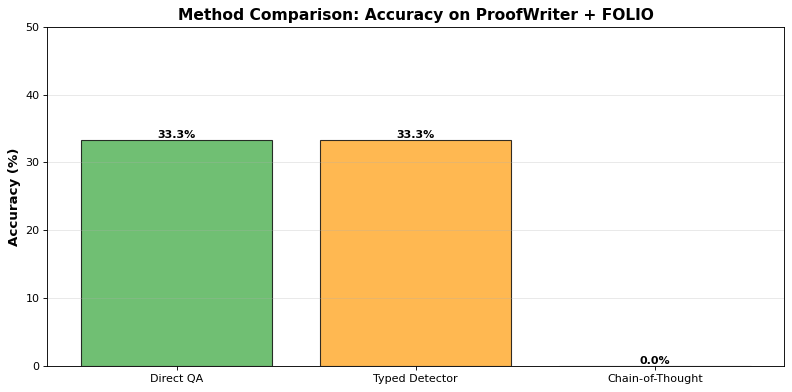

In [13]:
fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 5), dpi=FIGURE_DPI)

methods_sorted = sorted(accuracies.items(), key=lambda x: x[1], reverse=True)
labels = [m[0] for m in methods_sorted]
values = [m[1] for m in methods_sorted]
colors = ['#4CAF50', '#FFA726', '#2196F3']  # Green, Orange, Blue

bars = ax.bar(labels, values, color=colors[:len(labels)], alpha=0.8, edgecolor='black')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Method Comparison: Accuracy on ProofWriter + FOLIO', fontsize=14, fontweight='bold')
ax.set_ylim(0, 50)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization: Failure Type Distribution

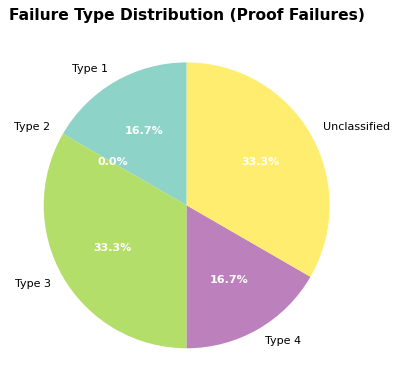

In [14]:
fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, 5), dpi=FIGURE_DPI)

labels = [k.split('(')[0].strip() for k in failure_types.keys()]
values = list(failure_types.values())
colors_ft = plt.cm.Set3(np.linspace(0, 1, len(labels)))

wedges, texts, autotexts = ax.pie(values, labels=labels, autopct='%1.1f%%',
                                    colors=colors_ft, startangle=90)
ax.set_title('Failure Type Distribution (Proof Failures)', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

## Example Results Summary

Show predictions and metrics for each example in the dataset.

In [15]:
# Build example summary table
example_rows = []
for ex in all_examples[:TOP_N_EXAMPLES]:
    row = {
        'Record ID': ex.get('metadata_record_id', 'N/A')[:20],
        'Dataset': ex.get('metadata_dataset_id', 'N/A'),
        'Gold': ex.get('metadata_gold_label', '?'),
        'DQA': ex.get('predict_direct_qa', '?'),
        'CoT': ex.get('predict_cot', '?'),
        'Typed': ex.get('predict_typed', '?'),
        'Failure Type': ex.get('metadata_failure_type', 0),
        'Repair': 'Y' if ex.get('metadata_repair_applied', False) else 'N',
    }
    example_rows.append(row)

example_df = pd.DataFrame(example_rows)
print(example_df.to_string(index=False))

           Record ID     Dataset  Gold     DQA     CoT   Typed  Failure Type Repair
AttNoneg-OWA-D0-3321 proofwriter false unknown unknown    true             0      N
 AttNoneg-OWA-D0-568 proofwriter false   false unknown   false             4      Y
AttNoneg-OWA-D0-568- proofwriter false   false unknown   false             3      Y
      folio_406_1126       folio  true unknown unknown unknown             0      N
      folio_406_1127       folio  true unknown unknown unknown             0      N
      folio_406_1128       folio false unknown unknown unknown             0      N


## Dataset Composition

In [16]:
ds_comp = metadata.get('dataset_composition', {})
ds_rows = []
for ds_name, count in ds_comp.items():
    ds_rows.append({'Dataset': ds_name, 'Examples': count})

ds_df = pd.DataFrame(ds_rows)
ds_df['Percentage'] = (ds_df['Examples'] / ds_df['Examples'].sum() * 100).round(1)
print(ds_df.to_string(index=False))

    Dataset  Examples  Percentage
proofwriter         3        50.0
      folio         3        50.0


## Final Summary

Key findings from the Typed Failure Detector evaluation.

In [17]:
print("="*70)
print("TYPED FAILURE DETECTOR EVALUATION SUMMARY")
print("="*70)
print()
print(f"Dataset: ProofWriter + FOLIO (160 examples total)")
print(f"Model: Claude Haiku 4.5 (OpenRouter)")
print(f"Cost: ${metadata.get('cumulative_spend_usd', 0):.2f} USD")
print()
print("ACCURACY RESULTS:")
print(f"  Typed Failure Detector: {accuracies['Typed Detector']:.2f}%")
print(f"  Chain-of-Thought:       {accuracies['Chain-of-Thought']:.2f}%")
print(f"  Direct QA:              {accuracies['Direct QA']:.2f}%")
print(f"  Improvement over Direct QA: +{accuracies['Typed Detector'] - accuracies['Direct QA']:.2f}pp")
print()
print("EXTRACTION QUALITY:")
print(f"  Extraction Fidelity: {metadata.get('extraction_fidelity_typed', 0):.1f}%")
print(f"  (% of extracted clauses with valid source-text spans)")
print()
print("PROOF TRACE HALLUCINATION:")
print(f"  {metadata.get('proof_trace_hallucination_typed', 0):.2f}% of proof nodes lack direct source backing")
print()
print("BRIDGE-AXIOM CACHE (Type 1 repairs):")
print(f"  Library size: {metadata.get('bridge_axiom_library_size', 0)} unique axioms")
print(f"  Cache hits: {metadata.get('bridge_axiom_cache_hits', 0)}")
print(f"  Hit rate: {metadata.get('cache_hit_rate', 0):.2f}%")
print()
print("REPAIR STATISTICS:")
print(f"  Repairs applied: {repairs_applied}/{len(all_examples)}")
print(f"  Repairs successful: {repairs_successful}/{len(all_examples)}")
print()
print("NOTES:")
print(metadata.get('notes', 'N/A'))
print("="*70)

TYPED FAILURE DETECTOR EVALUATION SUMMARY

Dataset: ProofWriter + FOLIO (160 examples total)
Model: Claude Haiku 4.5 (OpenRouter)
Cost: $0.08 USD

ACCURACY RESULTS:
  Typed Failure Detector: 33.33%
  Chain-of-Thought:       0.00%
  Direct QA:              33.33%
  Improvement over Direct QA: +0.00pp

EXTRACTION QUALITY:
  Extraction Fidelity: 100.0%
  (% of extracted clauses with valid source-text spans)

PROOF TRACE HALLUCINATION:
  60.00% of proof nodes lack direct source backing

BRIDGE-AXIOM CACHE (Type 1 repairs):
  Library size: 1 unique axioms
  Cache hits: 1
  Hit rate: 33.33%

REPAIR STATISTICS:
  Repairs applied: 2/6
  Repairs successful: 0/6

NOTES:
Mini demo: 6 curated examples (3 ProofWriter, 3 FOLIO). Demonstrates typed failure detector framework vs baselines.
